In [2]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# --- 1. Load Your Original Data ---
df_raw = pd.read_csv('Air Traffic Data Final.csv')
df_raw.head()

,Date,dom_pass,int_pass,dom_freight,int_freight,gdp,population,jet_fuel,inflation,unemployment,exchange_rate
0,01-01-2009,3288004.0,885435.0,20832.0,11675.0,1.341890e+12,1225524753,71.75,10.88,7.66,48.70
1,02-01-2009,3293220.0,757168.0,18645.0,12482.0,1.341890e+12,1225524753,61.97,10.88,7.66,49.25
2,03-01-2009,3122400.0,848046.0,23046.0,15359.0,1.341890e+12,1225524753,65.01,10.88,7.66,51.13
3,04-01-2009,3266686.0,861715.0,21623.0,14512.0,1.341890e+12,1225524753,68.55,10.88,7.66,49.97
4,05-01-2009,3883887.0,898410.0,19534.0,14586.0,1.341890e+12,1225524753,72.22,10.88,7.66,48.51


In [3]:
date_column_name = df_raw.columns[0]
df_raw[date_column_name] = pd.to_datetime(df_raw[date_column_name])
df_raw.set_index(date_column_name, inplace=True)
df_raw.sort_index(inplace=True)

In [4]:
df_raw = df_raw.astype('float64')

In [5]:
# --- 3. Save the Cleaned Historical Data ---
df_raw.to_csv('preprocessed_historical_data.csv')
print("Saved 'preprocessed_historical_data.csv'.")

Saved 'preprocessed_historical_data.csv'.


In [6]:
# --- 4. Generate Realistic Future Exogenous Data (15 steps) ---
print("Generating 15-step future exogenous data...")
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']
last_date = df_raw.index[-1]
freq = pd.infer_freq(df_raw.index)
if freq is None:
    print("Could not infer frequency, assuming 'MS' (Month Start).")
    freq = 'MS'
else:
    print(f"Inferred frequency: {freq}")

Generating 15-step future exogenous data...
Inferred frequency: MS


In [7]:
# Generate 16 periods to get 15 future dates
future_dates = pd.date_range(start=last_date, periods=16, freq=freq)[1:]
df_future_exog = pd.DataFrame(index=future_dates)

In [8]:
n_forecast_steps = 15
for col in exog_cols:
    diffs = df_raw[col].diff().dropna()
    diff_mean = diffs.mean()
    diff_std = diffs.std()
    last_value = df_raw[col].iloc[-1]
    shocks = np.random.normal(loc=diff_mean, scale=diff_std, size=n_forecast_steps)
    forecast = last_value + np.cumsum(shocks)
    df_future_exog[col] = forecast

In [9]:
print("\n--- Generated 'df_future_exog' (15 steps) ---")
print(df_future_exog.head())

# --- 5. Save the Future Exogenous Data ---
df_future_exog.to_csv('future_exog_data_15steps.csv')
print("Saved 'future_exog_data_15steps.csv'.")

print("\n✅ All necessary files have been generated (15-step horizon)!")


--- Generated 'df_future_exog' (15 steps) ---
                     gdp    population    jet_fuel  inflation  unemployment  \
2025-01-01  3.958144e+12  1.440595e+09  169.865002   4.575936      4.082842   
2025-02-01  3.962695e+12  1.437663e+09  196.990316   4.325387      4.026352   
2025-03-01  4.017886e+12  1.440056e+09  197.352678   4.798075      3.779563   
2025-04-01  4.129477e+12  1.437544e+09  182.736689   4.930768      3.514198   
2025-05-01  4.127849e+12  1.433008e+09  195.091360   4.059604      3.664028   

            exchange_rate  
2025-01-01      85.302545  
2025-02-01      85.572334  
2025-03-01      85.472932  
2025-04-01      85.747229  
2025-05-01      84.033026  
Saved 'future_exog_data_15steps.csv'.

✅ All necessary files have been generated (15-step horizon)!


# Forecast

Successfully loaded historical and 15-step future data.
Decomposing 'dom_pass' series...

--- Training 'dom_pass' (Decomposition) Model ---
'dom_pass' model trained.

--- Generating Forecasts for all horizons ---

--- HORIZON: 5 STEPS ---

--- HORIZON: 10 STEPS ---

--- HORIZON: 15 STEPS ---


   🚀 FINAL FORECASTS 🚀

--- 5-Step Forecast for Domestic Passengers ---
           dom_pass_forecast
2025-01-01        13,519,833
2025-02-01        13,220,498
2025-03-01        13,731,287
2025-04-01        13,728,296
2025-05-01        13,983,496
Saved forecast_plot_dom_pass_5steps.png

--- 10-Step Forecast for Domestic Passengers ---
           dom_pass_forecast
2025-01-01        13,519,833
2025-02-01        13,220,498
2025-03-01        13,731,287
2025-04-01        13,728,296
2025-05-01        13,983,496
2025-06-01        13,559,237
2025-07-01        13,452,091
2025-08-01        13,516,548
2025-09-01        13,410,759
2025-10-01        13,919,894
Saved forecast_plot_dom_pass_10steps.png

--- 15-S

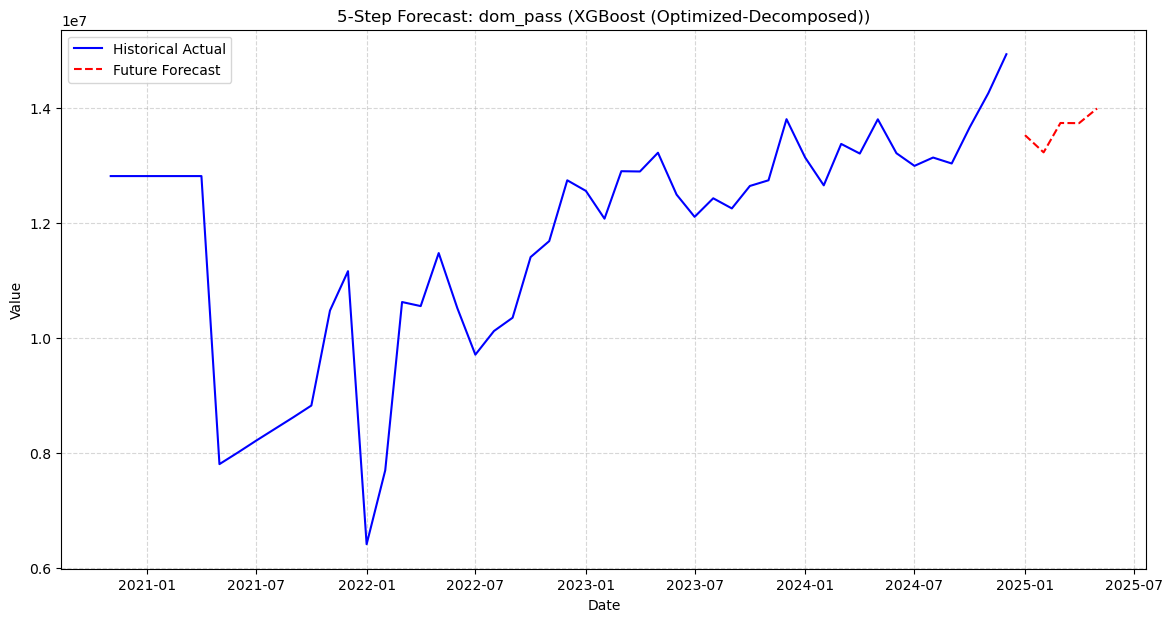

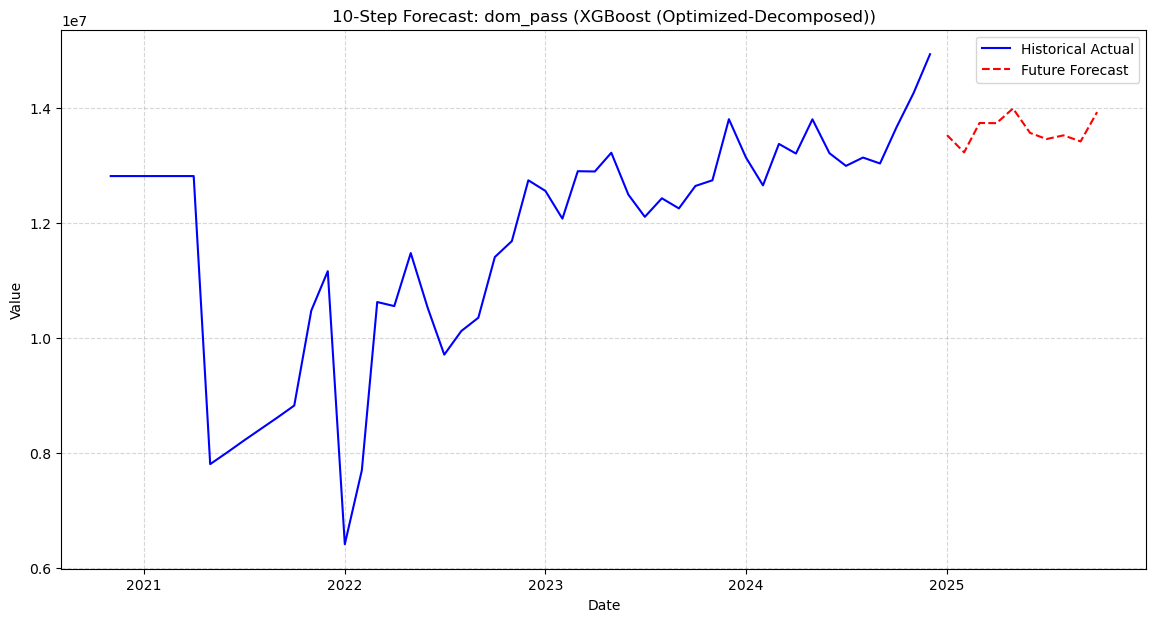

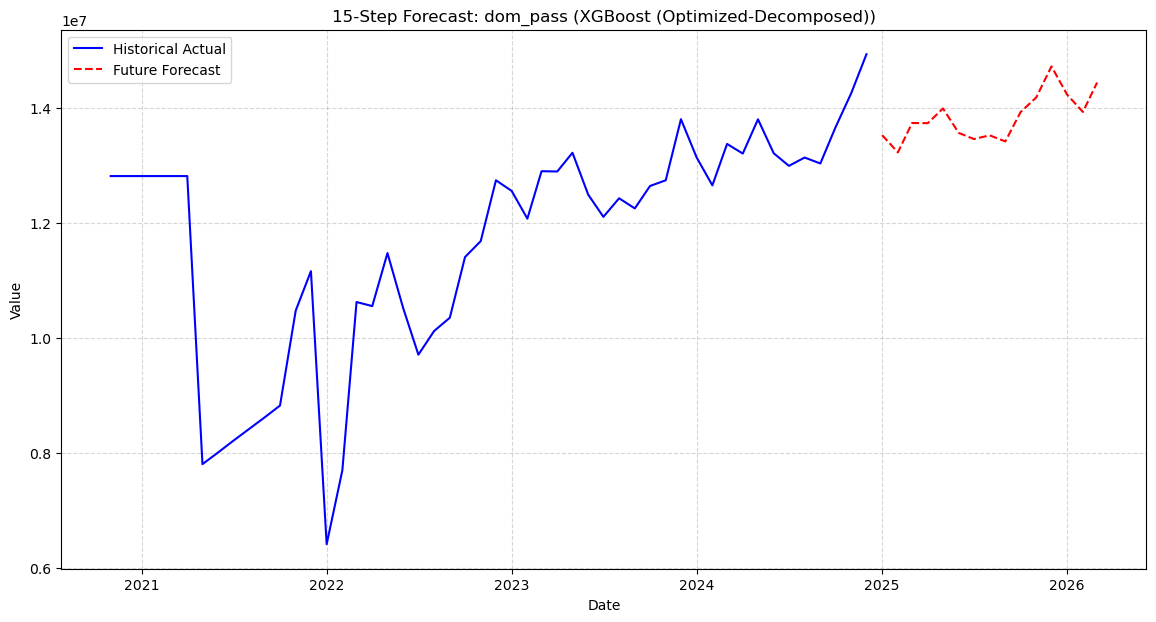

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# --- 1. Load Data (Generated in the previous step) ---

df_raw = pd.read_csv('preprocessed_historical_data.csv', index_col=0, parse_dates=True)
df_future_exog = pd.read_csv('future_exog_data_15steps.csv', index_col=0, parse_dates=True)
print("Successfully loaded historical and 15-step future data.")


# Define Columns
target_cols = ['dom_pass', 'int_pass', 'dom_freight', 'int_freight']
exog_cols = ['gdp', 'population', 'jet_fuel', 'inflation', 'unemployment', 'exchange_rate']

# --- 2. Decompose 'dom_pass' (The Optimized Solution) ---
print("Decomposing 'dom_pass' series...")
# Use additive model as the variance doesn't seem to grow with the trend
decomposition = seasonal_decompose(df_raw['dom_pass'], model='additive', period=12)
df_raw['dom_pass_trend'] = decomposition.trend
df_raw['dom_pass_seasonal'] = decomposition.seasonal
df_raw['dom_pass_resid'] = decomposition.resid

# --- 3. Feature Engineering Functions ---

def create_residual_features(df):
    """
    OPTIMIZED PATH: For dom_pass (Residuals)
    This function creates features to predict the RESIDUALS.
    """
    df_with_features = df.copy()
    
    # --- Outlier Detection (Still important for residuals) ---
    rolling_mean = df_with_features['dom_pass'].shift(1).rolling(window=12).mean()
    rolling_std = df_with_features['dom_pass'].shift(1).rolling(window=12).std()
    threshold = rolling_mean - (3 * rolling_std) # 3 standard deviations below mean
    df_with_features['is_outlier'] = (df_with_features['dom_pass'] < threshold).astype(int)
    
    n_lags = 6 # Using the 6-lag set that worked best
    
    # Define all columns that will be used to create features
    cols_to_lag = target_cols + exog_cols + ['is_outlier', 'dom_pass_trend', 'dom_pass_seasonal']
    
    for col in cols_to_lag:
        if col in df_with_features.columns:
            for i in range(1, n_lags + 1):
                df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
            
    # Time features (still useful for residuals)
    df_with_features['month'] = df_with_features.index.month
    
    # Add lags of the target-to-be-predicted (the residual)
    for i in range(1, n_lags + 1):
        df_with_features[f'dom_pass_resid_lag_{i}'] = df_with_features['dom_pass_resid'].shift(i)
        
    df_with_features = df_with_features.dropna()
    return df_with_features

def create_baseline_features(df):
    """
    STANDARD PATH: For dom_freight (Baseline)
    This was the best feature set for freight (12 lags).
    """
    n_lags = 12
    df_with_features = df.copy()
    for col in (target_cols + exog_cols):
        for i in range(1, n_lags + 1):
            df_with_features[f'{col}_lag_{i}'] = df_with_features[col].shift(i)
    df_with_features = df_with_features.dropna()
    return df_with_features

# --- 4. Recursive Forecasting Functions ---

def forecast_residuals_recursive(model, scaler_X, scaler_y, 
                                 df_history, df_future_exog_full, 
                                 forecasted_trend, forecasted_seasonal, 
                                 n_steps):
    """
    Recursive forecaster for the DECOMPOSITION model.
    """
    history_copy = df_history.copy()
    predictions = []
    
    df_future_exog_sliced = df_future_exog_full.iloc[:n_steps]

    for i in range(n_steps):
        future_date = df_future_exog_sliced.index[i]
        future_exog_row = df_future_exog_sliced.iloc[[i]].copy()
        
        # Add the 'known' future trend and seasonal parts
        future_exog_row['dom_pass_trend'] = forecasted_trend.iloc[i]
        future_exog_row['dom_pass_seasonal'] = forecasted_seasonal.iloc[i]

        temp_df = pd.concat([history_copy, future_exog_row])
        df_features_full = create_residual_features(temp_df)
        
        feature_names = scaler_X.get_feature_names_out()
        X_to_predict_df = pd.DataFrame(columns=feature_names, index=[future_date])
        last_feature_row = df_features_full.iloc[[-1]]
        
        for col in feature_names:
            if col in last_feature_row.columns:
                X_to_predict_df[col] = last_feature_row[col].values
        
        X_to_predict_df = X_to_predict_df.fillna(0) # Fill any gaps

        X_to_predict_scaled = scaler_X.transform(X_to_predict_df)
        y_pred_scaled = model.predict(X_to_predict_scaled)
        y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
        
        predictions.append(y_pred_original)
        
        # Update history for the next loop
        history_copy.loc[future_date, 'dom_pass_resid'] = y_pred_original
        for col in df_future_exog_sliced.columns:
            if col in history_copy.columns:
                 history_copy.loc[future_date, col] = future_exog_row[col].values[0]
        history_copy.loc[future_date, 'dom_pass_trend'] = forecasted_trend.iloc[i]
        history_copy.loc[future_date, 'dom_pass_seasonal'] = forecasted_seasonal.iloc[i]
        history_copy.loc[future_date, 'dom_pass'] = forecasted_trend.iloc[i] + forecasted_seasonal.iloc[i] + y_pred_original

    return pd.Series(predictions, index=df_future_exog_sliced.index)

def forecast_ml_recursive(target_name, feature_gen_function, model, scaler_X, scaler_y, 
                          df_history, df_future_exog_full, n_steps):
    """
    Recursive forecaster for the STANDARD (non-decomposed) model.
    """
    history_copy = df_history.copy()
    predictions = []
    
    df_future_exog_sliced = df_future_exog_full.iloc[:n_steps]

    for i in range(n_steps):
        future_date = df_future_exog_sliced.index[i]
        future_exog_row = df_future_exog_sliced.iloc[[i]].copy()

        temp_df = pd.concat([history_copy, future_exog_row])
        df_features_full = feature_gen_function(temp_df)
        
        feature_names = scaler_X.get_feature_names_out()
        
        X_to_predict_df = pd.DataFrame(columns=feature_names, index=[future_date])
        last_feature_row = df_features_full.iloc[[-1]]
        for col in feature_names:
            if col in last_feature_row.columns:
                X_to_predict_df[col] = last_feature_row[col].values
        X_to_predict_df = X_to_predict_df.fillna(0) 

        X_to_predict_scaled = scaler_X.transform(X_to_predict_df)
        y_pred_scaled = model.predict(X_to_predict_scaled)
        y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()[0]
        
        predictions.append(y_pred_original)
        
        # Update history
        history_copy.loc[future_date, target_name] = y_pred_original
        for col in df_future_exog_sliced.columns:
            if col in history_copy.columns:
                history_copy.loc[future_date, col] = future_exog_row[col].values[0]

    return pd.Series(predictions, index=df_future_exog_sliced.index)

# --- 5. Plot Forecast Function ---

def plot_forecast(df_history, forecast_series, target_name, model_name, n_steps):
    """Plots the historical data and the future forecast."""
    plt.figure(figsize=(14, 7))
    plt.plot(df_history.index[-50:], df_history[target_name].iloc[-50:], 
             label='Historical Actual', color='blue')
    plt.plot(forecast_series.index, forecast_series, 
             label='Future Forecast', color='red', linestyle='--')
    plt.title(f'{n_steps}-Step Forecast: {target_name} ({model_name})')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    # Save the plot
    plt.savefig(f'forecast_plot_{target_name}_{n_steps}steps.png')
    print(f"Saved forecast_plot_{target_name}_{n_steps}steps.png")

# --- 6. Main Execution ---

# 6a. === Train 'dom_pass' (OPTIMIZED) Residual Model ===
print("\n--- Training 'dom_pass' (Decomposition) Model ---")
df_resid_features = create_residual_features(df_raw)
X_full_pass = df_resid_features.drop(columns=[col for col in target_cols + ['dom_pass_trend', 'dom_pass_seasonal', 'dom_pass_resid'] if col in df_resid_features.columns])
y_full_pass = df_resid_features['dom_pass_resid']

scaler_X = StandardScaler()
scaler_X_resid = scaler_X.fit(X_full_pass)
X_full_pass_scaled = scaler_X_resid.transform(X_full_pass)

scaler_y = StandardScaler()
scaler_y_resid = scaler_y.fit(y_full_pass.to_frame())
y_full_pass_scaled = scaler_y_resid.transform(y_full_pass.to_frame())

resid_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)
resid_model.fit(X_full_pass_scaled, y_full_pass_scaled.ravel())
print("'dom_pass' model trained.")

# # 6b. === Train 'dom_freight' (Standard) Model ===
# print("\n--- Training 'dom_freight' (Baseline) Model ---")
# df_freight_features = create_baseline_features(df_raw)
# X_full_freight = df_freight_features.drop(columns=[col for col in target_cols if col in df_freight_features.columns])
# y_full_freight = df_freight_features['dom_freight']

# scaler_X_freight_final = StandardScaler().fit(X_full_freight)
# X_full_freight_scaled = scaler_X_freight_final.transform(X_full_freight)
# scaler_y_freight_final = StandardScaler().fit(y_full_freight.to_frame())
# y_full_freight_scaled = scaler_y_freight_final.transform(y_full_freight.to_frame())

# best_freight_params = {
#     'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7
# }
# final_freight_model = XGBRegressor(
#     objective='reg:squarederror', n_jobs=-1, random_state=42, **best_freight_params
# )
# final_freight_model.fit(X_full_freight_scaled, y_full_freight_scaled.ravel())
# print("'dom_freight' model trained.")

# 6c. === Generate Forecasts for 5, 10, 15 steps ===
forecast_horizons = [5, 10, 15]
all_forecasts = {}

print("\n--- Generating Forecasts for all horizons ---")

for n in forecast_horizons:
    print(f"\n--- HORIZON: {n} STEPS ---")
    
    # --- 'dom_pass' (OPTIMIZED Decomposition) ---
    
    # 1. Forecast Trend (FIXED)
    trend_df = df_raw[['dom_pass_trend']].dropna()
    # FIX: Use .values[0] to subtract scalars, not Series
    trend_slope = (trend_df.iloc[-1].values[0] - trend_df.iloc[-12].values[0]) / 12.0
    last_trend_value = trend_df.iloc[-1].values[0]

    future_trend_values = [last_trend_value + (i * trend_slope) for i in range(1, n + 1)]
    forecasted_trend = pd.Series(future_trend_values, index=df_future_exog.index[:n])

    # 2. Forecast Seasonality
    last_12_season = df_raw['dom_pass_seasonal'].dropna().iloc[-12:]
    # Repeat the seasonal cycle
    future_seasonal_values = [last_12_season.iloc[i % 12] for i in range(n)] 
    forecasted_seasonal = pd.Series(future_seasonal_values, index=df_future_exog.index[:n])

    # 3. Forecast Residuals
    forecasted_residuals = forecast_residuals_recursive(
        resid_model, scaler_X_resid, scaler_y_resid,
        df_raw, df_future_exog,
        forecasted_trend, forecasted_seasonal,
        n_steps=n
    )
    
    # 4. Combine
    final_forecast_pass = forecasted_trend + forecasted_seasonal + forecasted_residuals
    all_forecasts[f'dom_pass_{n}'] = final_forecast_pass
    
    # --- 'dom_freight' (Standard Model) ---
    # freight_forecast = forecast_ml_recursive(
    #     target_name='dom_freight',
    #     feature_gen_function=create_baseline_features,
    #     model=final_freight_model,
    #     scaler_X=scaler_X_freight_final,
    #     scaler_y=scaler_y_freight_final,
    #     df_history=df_raw,
    #     df_future_exog_full=df_future_exog,
    #     n_steps=n
    # )
    # all_forecasts[f'dom_freight_{n}'] = freight_forecast

# --- 7. Display Final Forecasts and Plots ---
print("\n\n" + "="*40)
print("   🚀 FINAL FORECASTS 🚀")
print("="*40)

for n in forecast_horizons:
    print(f"\n--- {n}-Step Forecast for Domestic Passengers ---")
    print(all_forecasts[f'dom_pass_{n}'].to_frame(name='dom_pass_forecast').applymap('{:,.0f}'.format))
    
    # print(f"\n--- {n}-Step Forecast for Domestic Freight ---")
    # print(all_forecasts[f'dom_freight_{n}'].to_frame(name='dom_freight_forecast').applymap('{:,.0f}'.format))
    
    # Plot the forecasts
    plot_forecast(df_raw, all_forecasts[f'dom_pass_{n}'], 'dom_pass', 'XGBoost (Optimized-Decomposed)', n)
    # plot_forecast(df_raw, all_forecasts[f'dom_freight_{n}'], 'dom_freight', 'XGBoost (Tuned)', n)

print("\n✅ All forecasts and plots generated.")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error , mean_absolute_percentage_error , mean_squared_error

results = {}
print("\n--- Evaluating Model Performance ---")

print(f"\n--- Results for: {'dom_pass'} ---")
    
    # 1. Get the specific model and scaler
model = models['dom_pass']
scaler_y = scalers_y['dom_pass'] # Get the correct 'y' scaler
    
    # 2. Make predictions (on the scaled X_test data)
y_pred_scaled = model.predict(X_test_scaled)
    
    # 3. Get the true scaled values
y_test_scaled_true = y_test_scaled['dom_pass']
    
    # 4. Inverse Transform - Get back to original units
    # We use the original 'y_test' DataFrame for the true values
y_test_original = y_test['dom_pass']
    
    # Inverse transform the predictions
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    # 5. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
epsilon = 1e-10 
mape = np.mean(np.abs((y_test_original - y_pred_original) / (y_test_original + epsilon))) * 100
    
print(f"RMSE: {rmse:.2f} (in original units)")
print(f"MAE:  {mae:.2f} (in original units)")
print(f"MAPE: {mape:.2f} %")
    
results['dom_pass'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

    # --- 6. Plot the results ---
plt.figure(figsize=(12, 6))
    # We must use the index from the y_test DataFrame to plot correctly
plt.plot(y_test_original.index, y_test_original, label='Actual Values', color='blue')
plt.plot(y_test_original.index, y_pred_original, label='Predicted Values', color='red', linestyle='--')
plt.title(f'XGBoost Prediction vs Actual for {'dom_pass'}')
plt.xlabel('Date')
plt.ylabel('Original Units (Passengers/Tonnes)')
plt.legend()
plt.show()

print("\n--- Performance Summary (XGBoost) ---")
results_df = pd.DataFrame(results).T
print(results_df)

Next
